In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv("heart.csv")   # keep heart.csv in the same folder as your notebook
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.info()

Shape: (918, 12)

Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [6]:

print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())

Cholesterol == 0: 172
RestingBP == 0: 1


HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


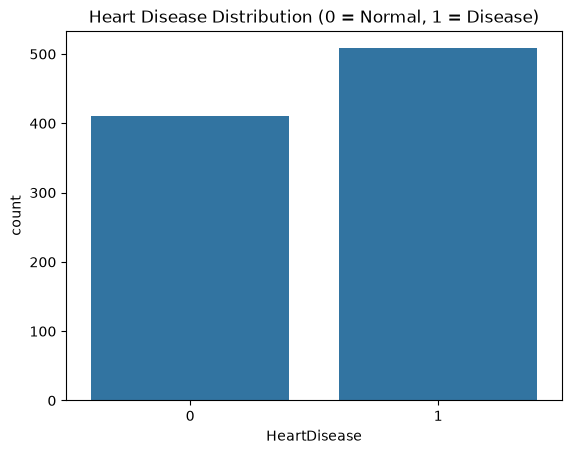

In [7]:
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True).round(3))

sns.countplot(x="HeartDisease", data=df)
plt.title("Heart Disease Distribution (0 = Normal, 1 = Disease)")
plt.show()

In [8]:
# 1 row with RestingBP = 0 -> just drop it
df = df[df["RestingBP"] != 0].reset_index(drop=True)

# Cholesterol = 0 is missing data -> mark as NaN (we'll impute after the train/test split)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

print("Shape:", df.shape)
print("Missing Cholesterol:", df["Cholesterol"].isnull().sum())

Shape: (917, 12)
Missing Cholesterol: 171


In [10]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


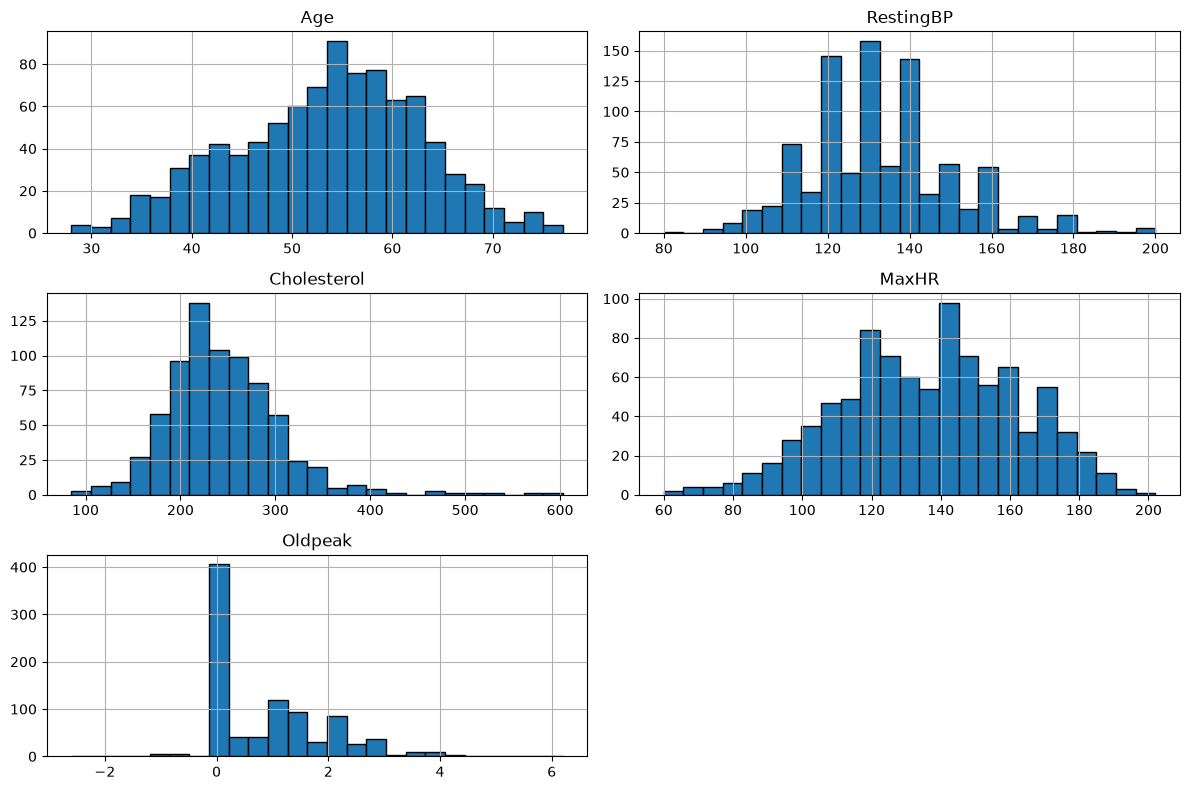

In [11]:
df[num_cols].hist(bins=25, figsize=(12, 8), edgecolor="black")
plt.tight_layout()
plt.show()

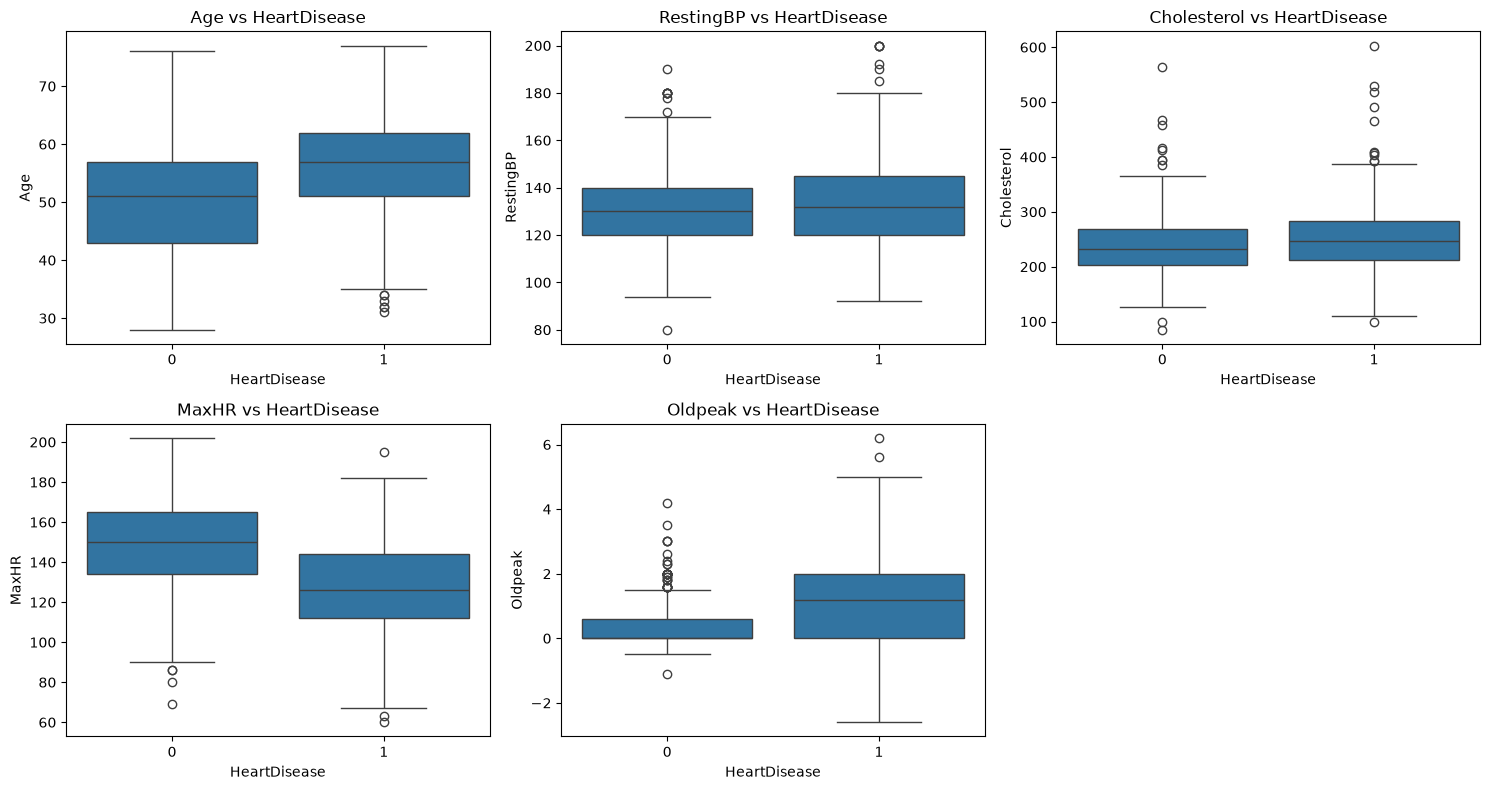

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="HeartDisease", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

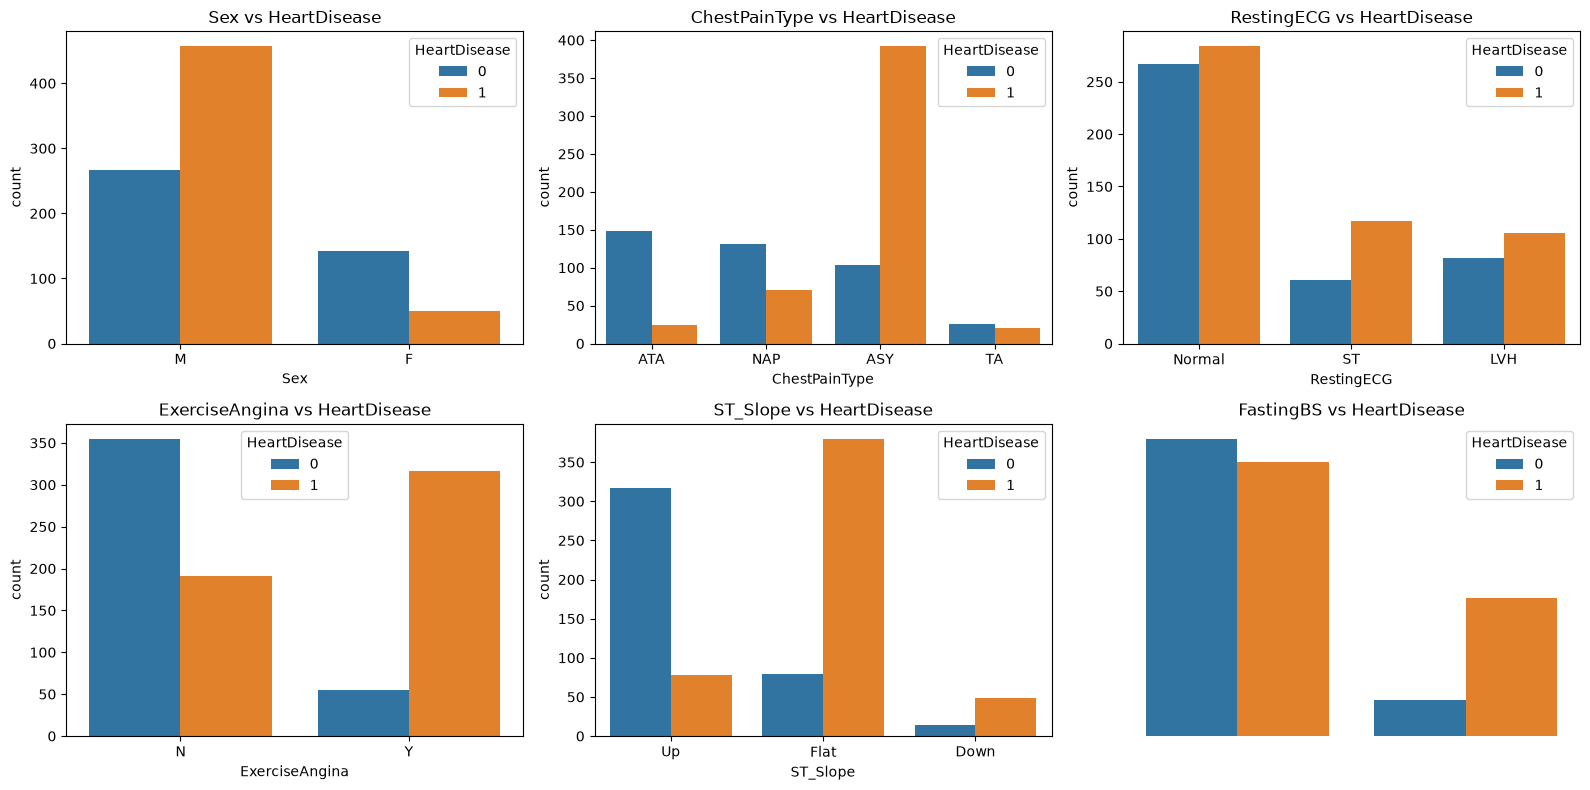

In [13]:
cat_plot_cols = cat_cols + ["FastingBS"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_plot_cols):
    sns.countplot(x=col, hue="HeartDisease", data=df, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

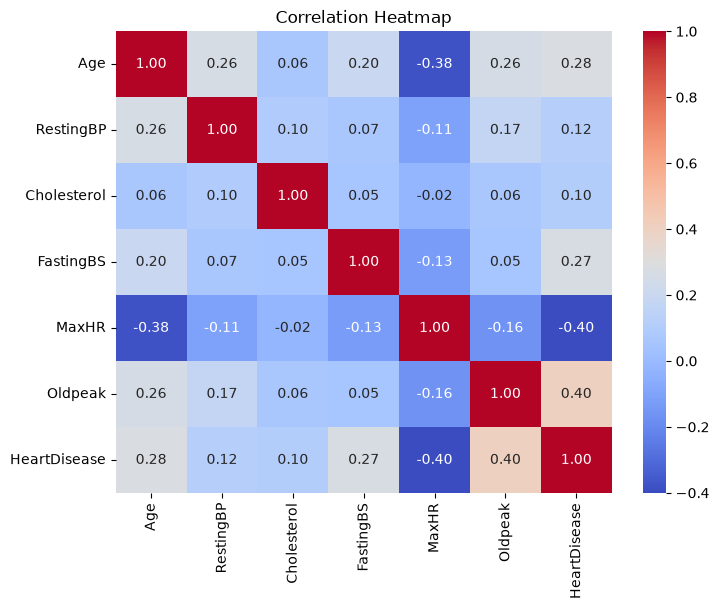

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (733, 11) | Test: (184, 11)


In [17]:
chol_median = X_train["Cholesterol"].median()

X_train["Cholesterol"] = X_train["Cholesterol"].fillna(chol_median)
X_test["Cholesterol"] = X_test["Cholesterol"].fillna(chol_median)

print("Median used:", chol_median)
print("Missing left:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

Median used: 239.0
Missing left: 0 0


In [18]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# make sure both have identical columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape)
X_train.head()

(733, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
161,49,128,212.0,0,96,0.0,True,False,False,False,True,False,True,True,False
603,68,134,254.0,1,151,0.0,True,False,True,False,True,False,True,False,True
658,59,126,218.0,1,134,2.2,True,False,True,False,True,False,False,True,False
792,67,125,254.0,1,163,0.2,True,False,False,False,True,False,False,True,False
140,52,160,331.0,0,94,2.5,True,False,False,False,True,False,True,True,False


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [21]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))
print("\n", classification_report(y_test, y_pred_lr))

Accuracy : 0.8859
ROC-AUC  : 0.9399

               precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



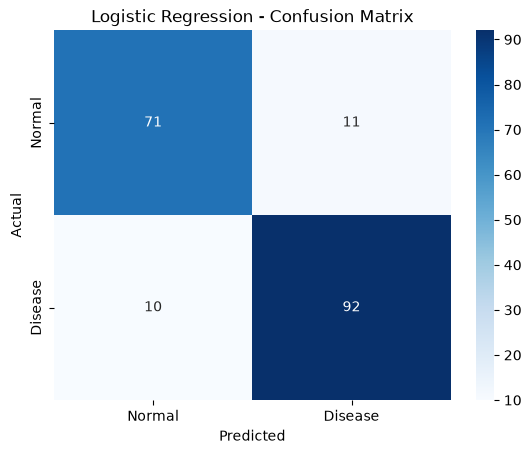

In [22]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Disease"], yticklabels=["Normal", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

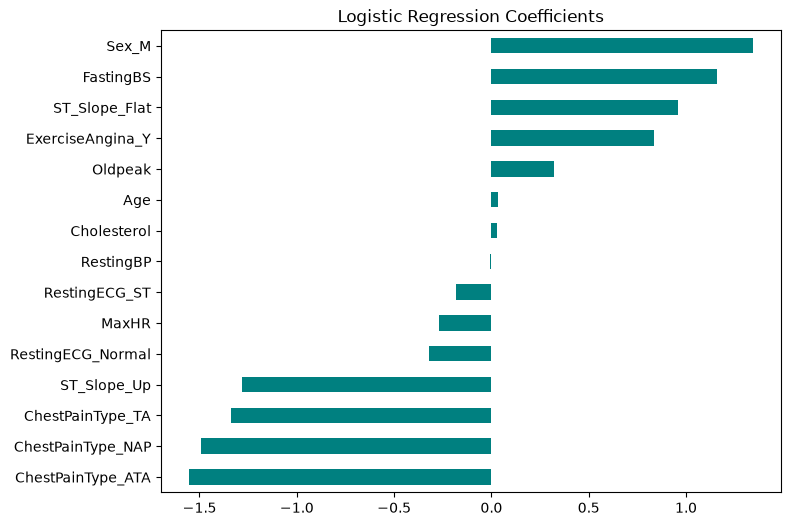

In [23]:
coef = pd.Series(lr.coef_[0], index=X_train_scaled.columns).sort_values()

coef.plot(kind="barh", figsize=(8, 6), color="teal")
plt.title("Logistic Regression Coefficients")
plt.show()

In [24]:
results = {}

def store_results(name, y_true, y_pred, y_prob):
    results[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }

store_results("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
pd.DataFrame(results).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8859,0.8932,0.902,0.8976,0.9399


In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_knn), 4))

Accuracy : 0.8641
ROC-AUC  : 0.9209


Best k: 19 | CV accuracy: 0.8484


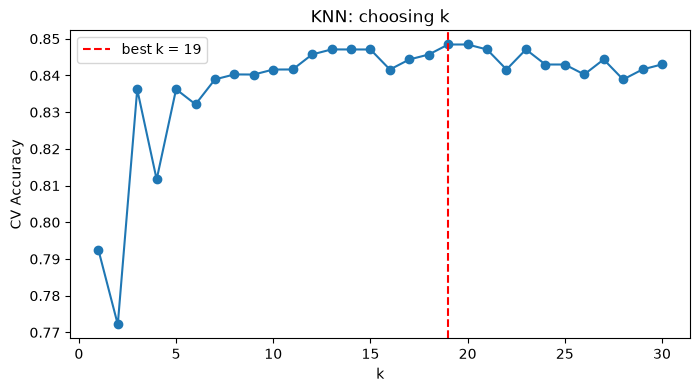

In [26]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(score)

best_k = k_values[np.argmax(cv_scores)]
print("Best k:", best_k, "| CV accuracy:", round(max(cv_scores), 4))

plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("KNN: choosing k")
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



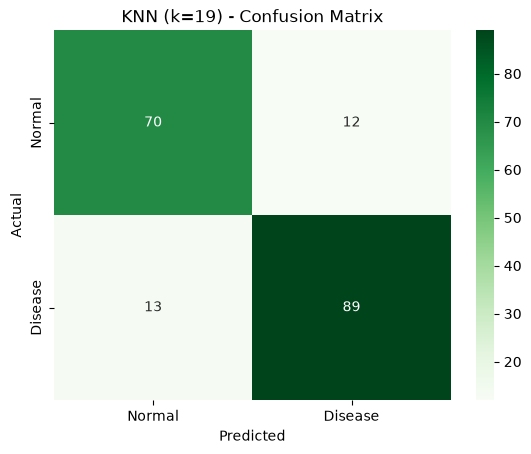

In [27]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Normal", "Disease"], yticklabels=["Normal", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN (k={best_k}) - Confusion Matrix")
plt.show()

In [28]:
store_results("KNN", y_test, y_pred_knn, y_prob_knn)
pd.DataFrame(results).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8859,0.8932,0.9020,0.8976,0.9399
KNN,0.8641,0.8812,0.8725,0.8768,0.9277


In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

print("Train accuracy:", round(dt_base.score(X_train, y_train), 4))
print("Test accuracy :", round(dt_base.score(X_test, y_test), 4))

Train accuracy: 1.0
Test accuracy : 0.7772


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Best params:", grid_dt.best_params_)
print("Best CV accuracy:", round(grid_dt.best_score_, 4))

Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV accuracy: 0.843


Train accuracy: 0.8718
Test accuracy : 0.8043
ROC-AUC       : 0.8552

               precision    recall  f1-score   support

           0       0.78      0.78      0.78        82
           1       0.82      0.82      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



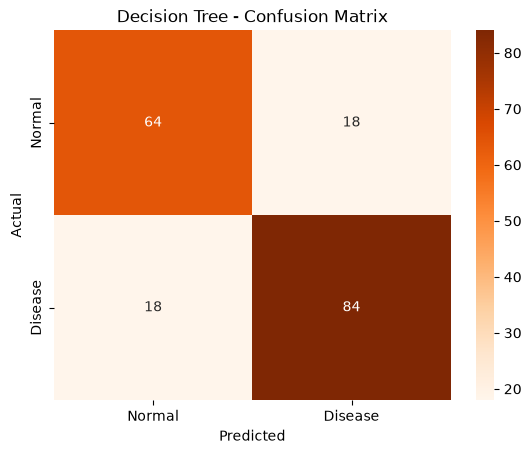

In [31]:
dt = grid_dt.best_estimator_

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(dt.score(X_train, y_train), 4))
print("Test accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("ROC-AUC       :", round(roc_auc_score(y_test, y_prob_dt), 4))
print("\n", classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Normal", "Disease"], yticklabels=["Normal", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

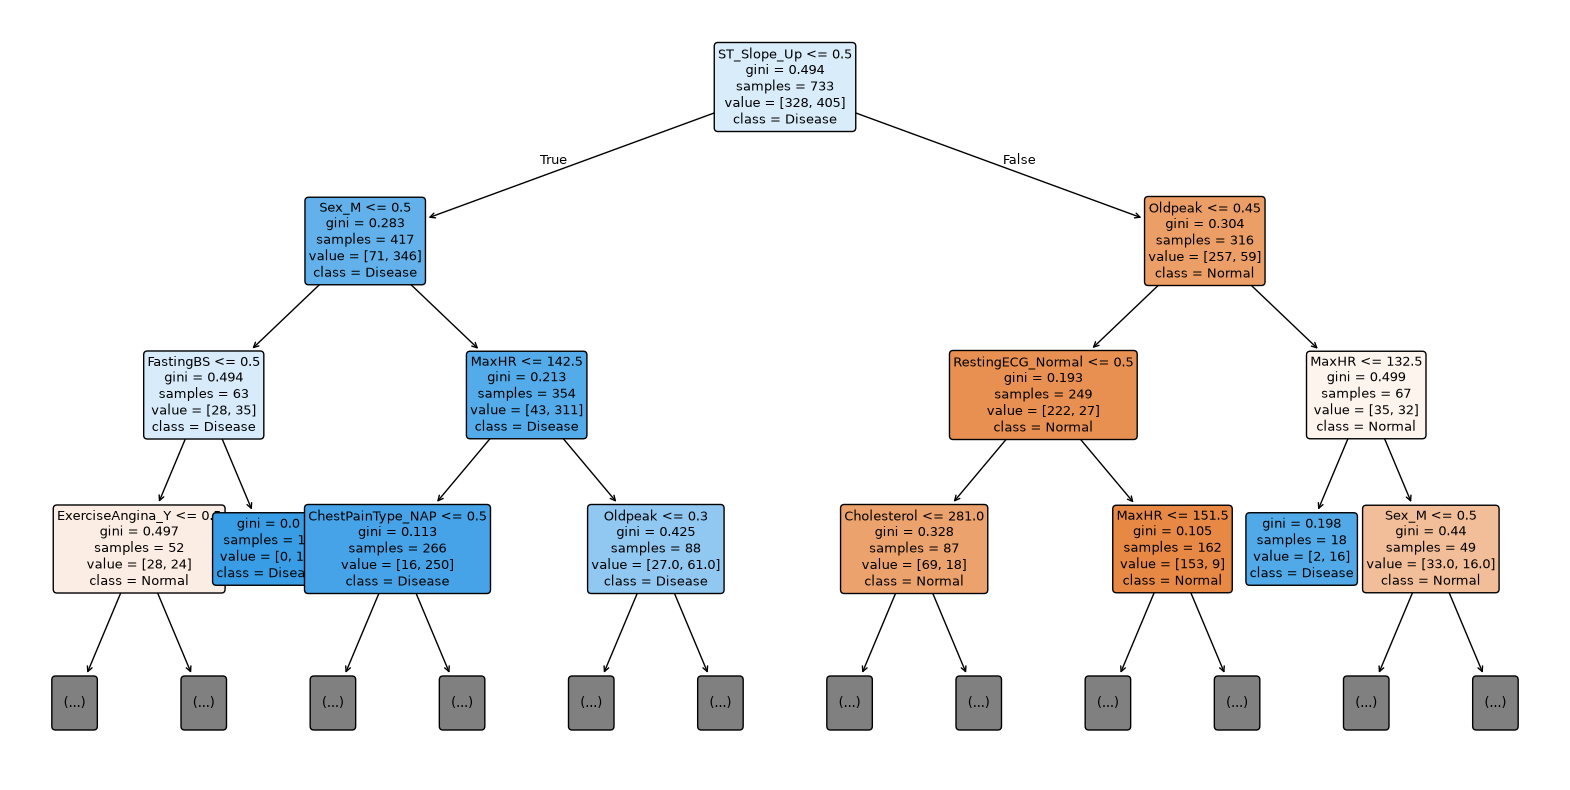

In [32]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X_train.columns, class_names=["Normal", "Disease"],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.show()

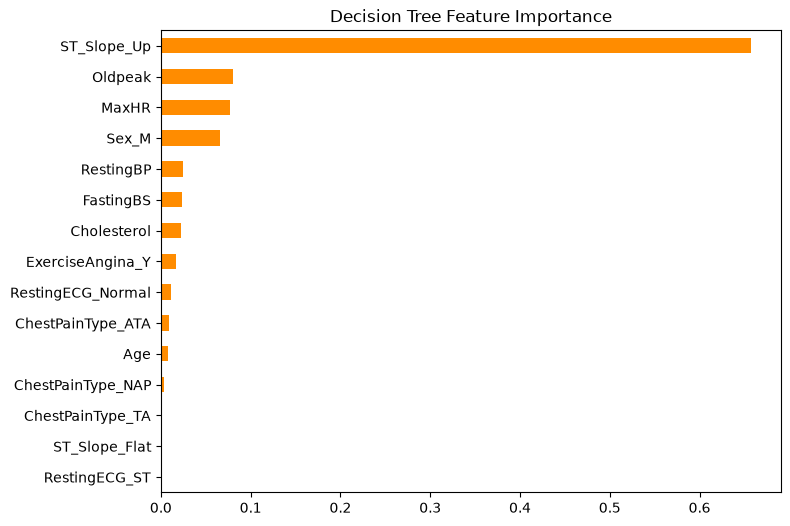

In [33]:
imp = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values()

imp.plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Decision Tree Feature Importance")
plt.show()

In [37]:
store_results("Decision Tree", y_test, y_pred_dt, y_prob_dt)
pd.DataFrame(results).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8859,0.8932,0.9020,0.8976,0.9399
KNN,0.8641,0.8812,0.8725,0.8768,0.9277
Decision Tree,0.8043,0.8235,0.8235,0.8235,0.8552


In [38]:
comparison = pd.DataFrame(results).T.round(4).sort_values("ROC-AUC", ascending=False)
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8859,0.8932,0.9020,0.8976,0.9399
KNN,0.8641,0.8812,0.8725,0.8768,0.9277
Decision Tree,0.8043,0.8235,0.8235,0.8235,0.8552


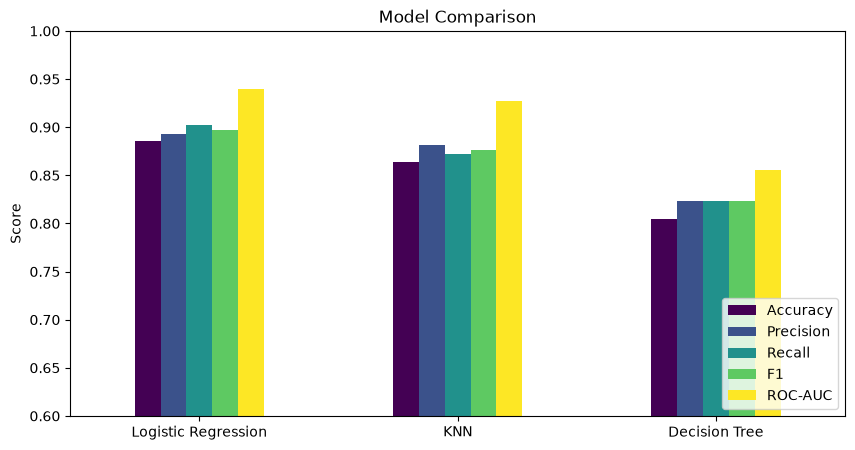

In [39]:
comparison.plot(kind="bar", figsize=(10, 5), colormap="viridis")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

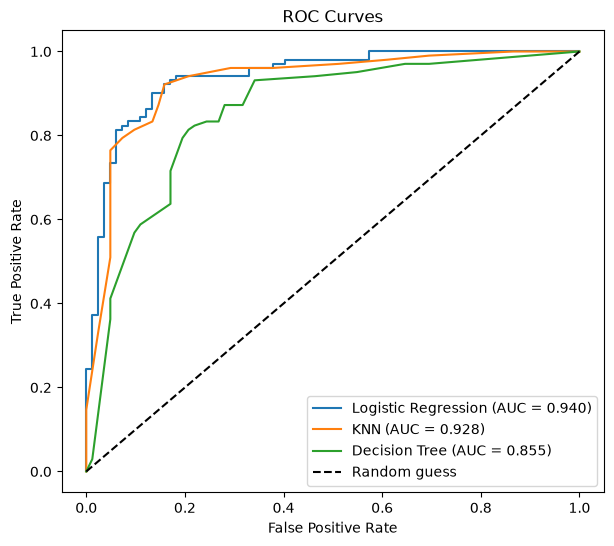

In [40]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, prob in [("Logistic Regression", y_prob_lr),
                   ("KNN", y_prob_knn),
                   ("Decision Tree", y_prob_dt)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [41]:
best_model = comparison["ROC-AUC"].idxmax()
print("Best model by ROC-AUC:", best_model)
print(comparison.loc[best_model])



Best model by ROC-AUC: Logistic Regression
Accuracy     0.8859
Precision    0.8932
Recall       0.9020
F1           0.8976
ROC-AUC      0.9399
Name: Logistic Regression, dtype: float64


In [42]:
import joblib

joblib.dump(lr, "heart_model.pkl")       # swap lr for knn_best or dt if that one wins
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']